In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch import Tensor

device = "cuda"

In [9]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((64, 64)), 
    transforms.ToTensor(), 
    transforms.Normalize(mean = [0.5] * 3, std = [0.5] * 3)])

train_dataset = ImageFolder(root="datasets/afhq_cat/train", transform=transform)
val_dataset = ImageFolder(root="datasets/afhq_cat/val", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=4, pin_memory=True)

In [10]:
from torch.optim import AdamW

from practice.diffusion.inhu_diffusijon_model import InhuDiffusionModel
from practice.diffusion.inhu_res_unet import InhuResUnet

TOTAL_TIME = 4000
TIME_DIM = 256

unet = InhuResUnet(channels=[32, 64, 128, 256, 512, 512], attention_start_idx=4).to(device)
model = InhuDiffusionModel(unet=unet, time_dim= TIME_DIM, total_timestep=TOTAL_TIME).to(device)
optimizer = AdamW(model.parameters(), lr=1e-4)
loss_fn = F.mse_loss

total_train_loss_history:list[float] = []
total_val_loss_history:list[float] = []

In [ ]:
#after saved model

from practice.diffusion.inhu_diffusijon_model import InhuDiffusionCheckpoint

def load_best_model():
    checkpoint:InhuDiffusionCheckpoint = torch.load(
        "trained_model/diffusion/best_model.pth",
        map_location=device
    )

    unet = InhuResUnet(
        channels=[32, 64, 128, 256, 512, 512],
        attention_start_idx=4,
    ).to(device)

    model = InhuDiffusionModel(
        unet=unet,
        time_dim=checkpoint["time_dim"],
        total_timestep=checkpoint["total_timestep"],
    ).to(device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    print("Loaded best model")
    print("current epoch idx:", checkpoint["epoch"])
    print("best epoch idx:", checkpoint["best_epoch"] )
    print("Best val loss:", checkpoint["best_val_loss"])
    
    return checkpoint, model

checkpoint, model = load_best_model()
history = checkpoint["history"]
total_train_loss_history = history["train_loss"]
total_val_loss_history = history["val_loss"]

Loaded best model
current epoch idx: 14
best epoch idx: 14
Best val loss: 0.04063235320150852


In [12]:
from typing import Optional

from practice.diffusion.image_noise_generator import get_noised_image
from pathlib import Path

def train(model:nn.Module, optimizer:torch.optim.Optimizer, loss_fn, 
          train_loader:DataLoader, val_loader:DataLoader, epoch_num:int, total_timestep=TOTAL_TIME, 
          save_dir:str = "trained_model/diffusion", checkpoint:Optional[InhuDiffusionCheckpoint] = None):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    
    train_loss:list[float] = []
    val_loss:list[float] = []
    best_val_loss = float("inf")
    best_epoch_idx:int = 0
    init_epoch_idx:int = 0
    
    #if model is loaded from checkpoint, then use that one
    if checkpoint is not None:
        train_loss = checkpoint["history"]["train_loss"]
        val_loss = checkpoint["history"]["val_loss"]
        best_epoch_idx = checkpoint["best_epoch"]
        best_val_loss = checkpoint["best_val_loss"]
        init_epoch_idx = checkpoint["epoch"] + 1
        
        for i in range(len(train_loss)):
            print(f"Epoch {i} | train_loss={train_loss[i]} | val_loss={val_loss[i]}")

    
    for i in range(init_epoch_idx,epoch_num):
        model.train()
        cur_train_loss:float = 0
        cur_val_loss:float = 0
        for images, label in train_loader:
            optimizer.zero_grad()
            
            images = images.to(device)
            random_time_steps:Tensor = torch.randint(0, total_timestep, (images.shape[0],), device=device)
            noised_images, noise = get_noised_image(random_time_steps, images, total_timestep)
            pred_noise, pred_original_image = model(noised_images, random_time_steps)
            loss = loss_fn(pred_noise, noise)
            loss.backward()
            optimizer.step()
            
            cur_train_loss += loss.item()
        
        with torch.no_grad():
            model.eval()
            for images, label in val_loader:
                images = images.to(device)
                random_time_steps:Tensor = torch.randint(0, total_timestep, (images.shape[0],), device=device)
                noised_images, noise = get_noised_image(random_time_steps, images, total_timestep)
                pred_noise, pred_original_image = model(noised_images, random_time_steps)
                loss = loss_fn(pred_noise, noise)
                
                cur_val_loss += loss.item()
        avg_train_loss = cur_train_loss / len(train_loader)
        avg_val_loss = cur_val_loss / len(val_loader)
        
        train_loss.append(avg_train_loss)
        val_loss.append(avg_val_loss)
    
        print(f"Epoch {i} | train_loss={train_loss[-1]} | val_loss={val_loss[-1]}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch_idx = i
            
            best_checkpoint: InhuDiffusionCheckpoint = {
                "epoch": best_epoch_idx,
                "best_epoch": best_epoch_idx,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_loss": best_val_loss,
                "history": {"train_loss": train_loss, "val_loss": val_loss},
                "total_timestep": total_timestep,
                "time_dim": TIME_DIM,
            }
            torch.save(best_checkpoint, save_dir / "best_model.pth")
        
        last_checkpoint: InhuDiffusionCheckpoint = {
                "epoch": i,
                "best_epoch": best_epoch_idx,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_loss": best_val_loss,
                "history": {"train_loss": train_loss, "val_loss": val_loss},
                "total_timestep": total_timestep,
                "time_dim": TIME_DIM,
            }
        torch.save(last_checkpoint, save_dir / "last_model.pth")
    
    return train_loss, val_loss


In [13]:
cur_train_loss, cur_val_loss = train(model, optimizer, loss_fn, train_loader, val_loader, 50, checkpoint=checkpoint)

total_train_loss_history = cur_train_loss
total_val_loss_history = cur_val_loss

Epoch 0 | train_loss=0.13925368686064304 | val_loss=0.07977936682105065
Epoch 1 | train_loss=0.06771470398387075 | val_loss=0.058917641043663024
Epoch 2 | train_loss=0.0615767979589085 | val_loss=0.05032515304908156
Epoch 3 | train_loss=0.05687070782986362 | val_loss=0.0555635842718184
Epoch 4 | train_loss=0.05441627712866842 | val_loss=0.0479707227665931
Epoch 5 | train_loss=0.05370634596952352 | val_loss=0.056577808614820244
Epoch 6 | train_loss=0.05094937624733482 | val_loss=0.049373706117272376
Epoch 7 | train_loss=0.0502062940135919 | val_loss=0.05091060633212328
Epoch 8 | train_loss=0.05083646878485963 | val_loss=0.049124129936099055
Epoch 9 | train_loss=0.049810078107774304 | val_loss=0.046202083807438614
Epoch 10 | train_loss=0.04737896476622998 | val_loss=0.04272084764204919
Epoch 11 | train_loss=0.04779105146648182 | val_loss=0.04738719604164362
Epoch 12 | train_loss=0.049008872175388345 | val_loss=0.04327942637354135
Epoch 13 | train_loss=0.04867098304331794 | val_loss=0.043

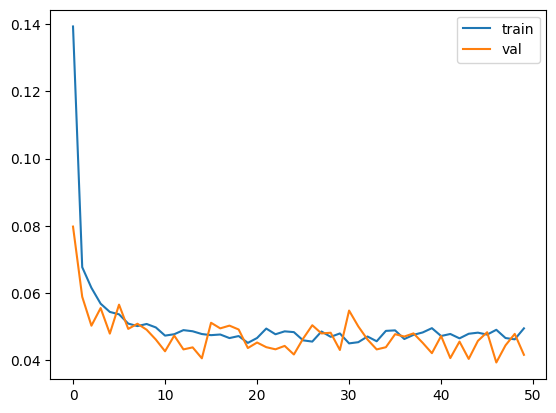

0.03939436513930559


In [15]:
import matplotlib.pyplot as plt

plt.plot(total_train_loss_history, label="train")
plt.plot(total_val_loss_history, label="val")
plt.legend()
plt.show()

print(min(cur_val_loss))

In [ ]:
model = load_best_model()
